In [5]:
import json
from pathlib import Path

from jsonschema import validate

repo_root = (
    Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[2]
)
EVALS_DIR = repo_root / "data" / "evals" / "chunking"


chunk_eval_report_schema_file = EVALS_DIR / "chunk_eval_report.schema.json"
chunk_eval_report = EVALS_DIR / "chunk_eval_report.json"

schema = json.loads(chunk_eval_report_schema_file.read_text())
report = json.loads(chunk_eval_report.read_text())

validation_result = validate(instance=report, schema=schema)

print(f"Validation result: {validation_result}")



Validation result: None


In [ ]:
# Verify episode metadata enrichment
import pandas as pd

repo_root = (
    Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[2]
)

ep = "0a4fa77e-bc0f-11ef-bab6-3f37b4906b43"
p = (
    repo_root
    / "data"
    / "chunks"
    / "sentence_bound"
    / f"episode_id={ep}"
    / "part-00000.snappy.parquet"
)

df = pd.read_parquet(p)
sorted(
    set(df.columns)
    & {
        "episode_title",
        "guest",
        "publish_date",
        "episode_number",
        "duration",
        "headline",
        "description",
    }
)


[]


=== Spike 3 — Chunking Eval Summary ===
        Method  Hit@10    MRR  AvgTokens  AvgDurationSec
         fixed     0.5 0.0625 681.122449      162.756122
sentence_bound     0.5 0.0625 611.757576      147.088773
   time_window     0.5 0.0500 790.920000      189.080380


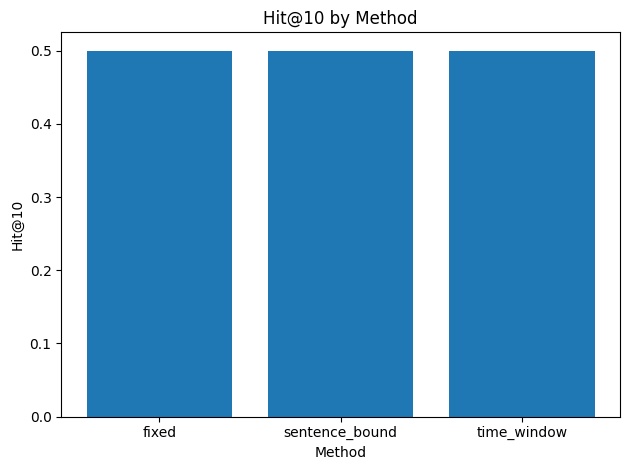

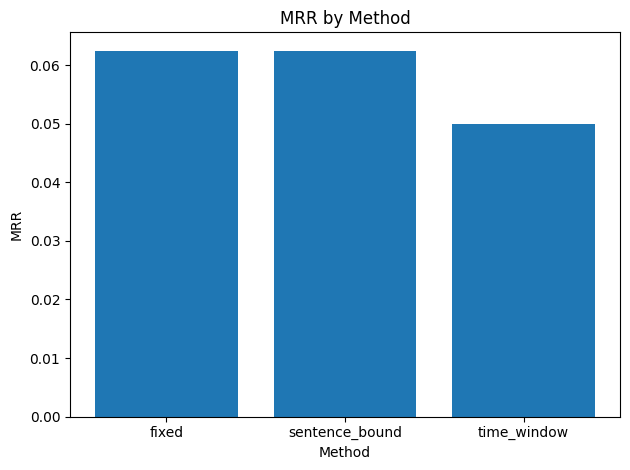

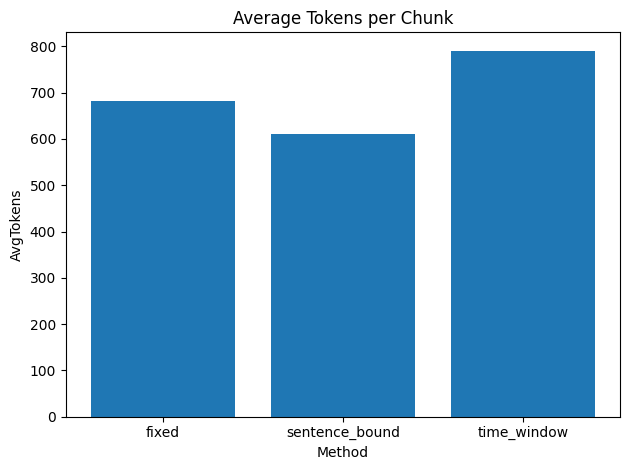

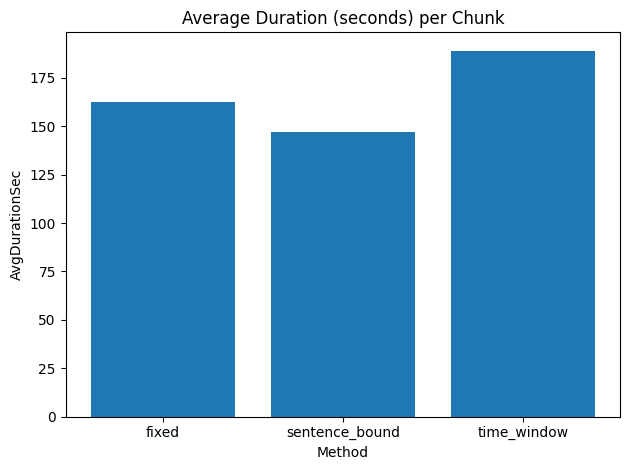

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

repo_root = (
    Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[2]
)

REPORT = repo_root / "data" / "evals" / "chunking" / "chunk_eval_report.json"

if not REPORT.exists():
    raise SystemExit(f"Missing {REPORT}. Run the eval step first.")

with REPORT.open() as f:
    report = json.load(f)

rows = []
for method, m in report["methods"].items():
    rows.append(
        {
            "Method": method,
            "Hit@10": m.get("Hit@10", 0.0),
            "MRR": m.get("MRR", 0.0),
            "AvgTokens": m.get("AvgTokens", 0.0),
            "AvgDurationSec": m.get("AvgDurationSec", 0.0),
        }
    )

df = pd.DataFrame(rows).sort_values("Method")
print("\n=== Spike 3 — Chunking Eval Summary ===")
print(df.to_string(index=False))

# Chart 1: Hit@10
plt.figure()
plt.bar(df["Method"], df["Hit@10"])
plt.title("Hit@10 by Method")
plt.xlabel("Method")
plt.ylabel("Hit@10")
plt.tight_layout()
plt.show()

# Chart 2: MRR
plt.figure()
plt.bar(df["Method"], df["MRR"])
plt.title("MRR by Method")
plt.xlabel("Method")
plt.ylabel("MRR")
plt.tight_layout()
plt.show()

# Chart 3: Avg Tokens (lower is better on ties)
plt.figure()
plt.bar(df["Method"], df["AvgTokens"])
plt.title("Average Tokens per Chunk")
plt.xlabel("Method")
plt.ylabel("AvgTokens")
plt.tight_layout()
plt.show()

# Chart 4: Avg Duration (s)
plt.figure()
plt.bar(df["Method"], df["AvgDurationSec"])
plt.title("Average Duration (seconds) per Chunk")
plt.xlabel("Method")
plt.ylabel("AvgDurationSec")
plt.tight_layout()
plt.show()
